# Assignment 1: Introduction to Language Modeling

**Deadline:** April 20

---

**Task markers:**
- 🎓 Suitable for oral exam discussion
- ⚙ Pure implementation task

---

## Part 0: Environment Setup

### Task 0.1 — Setting up the environment ⚙

Install the required libraries and download the provided data archive.

In [18]:
# !pip install nltk
# !pip install torch
# !pip install transformers
# !pip install datasets
# !pip install matplotlib
# !pip install scikit-learn

In [19]:
import torch
import torch.nn as nn
import numpy as np
from collections import Counter
from datasets import load_dataset
from torch.utils.data import DataLoader, Subset
from transformers import PretrainedConfig, PreTrainedModel

---

## Part 1: Tokenization

### Task 1.1 — Using NLTK or SpaCy for word splitting ⚙

Use `word_tokenize` from NLTK (or an equivalent SpaCy function) to split text into tokens.

Example: `word_tokenize("Let's test!!")` → `["Let", "'s", "test", "!", "!"]`

In [20]:
import nltk
nltk.download('punkt') 
#NLTK's pre-trained sentence and word tokenizer model.
nltk.download('punkt_tab')
from nltk import word_tokenize

# Sanity check
print(word_tokenize("Let's test!!"))

['Let', "'s", 'test', '!', '!']


[nltk_data] Downloading package punkt to /home/hoda/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/hoda/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [21]:
# Load dataset early — needed by Task 1.2 to build the vocabulary.
# (Task 2.1 below repeats this with more explanation.)

TRAIN_FILE = "data/wiki.train.tokens"
VAL_FILE   = "data/wiki.valid.tokens"

dataset = load_dataset('text', data_files={'train': TRAIN_FILE, 'val': VAL_FILE})
dataset = dataset.filter(lambda x: x['text'].strip() != '')
dataset['train'] = Subset(dataset['train'], range(1000))  # small subset for speed

print(f"Train: {len(dataset['train'])} | Val: {len(dataset['val'])}")

Train: 1000 | Val: 2461


### Task 1.2 — Building the vocabulary 🎓

Process training and validation paragraphs with the tokenizer (lowercase).  
Build a vocabulary that maps tokens to integers, including **4 special symbols**:
- Unknown token
- Beginning-of-sequence token
- End-of-sequence token
- Padding token

Limit vocabulary to `max_voc_size` using the most frequent tokens.  
Also create an inverse mapping (integer → string).

**Sanity checks:**
- Verify vocabulary size
- Special symbols exist without conflicts
- Common and rare words are handled appropriately
- Bidirectional mapping (token → id → token) works correctly

In [22]:
# Task 1.2 — Build vocabulary ( lookup table that converts words to numbers and back)
# Note: run the dataset loading cell (Task 2.1) first, then re-run this cell.

max_voc_size = 10000

# Special tokens
UNK = "<unk>"
BOS = "<bos>"
EOS = "<eos>"
PAD = "<pad>" #fills blank space when batching sentences of different lengths

counter = Counter()
for split in ("train", "val"):
    for item in dataset[split]:
        counter.update(word_tokenize(item['text'].lower()))

# TODO: Build voc (dict: str -> int) and inv_voc (dict: int -> str)
special_tokens = [PAD, UNK, BOS, EOS]
most_common = [word for word, _ in counter.most_common(max_voc_size - len(special_tokens))]
all_tokens = special_tokens + most_common

voc = {token: idx for idx, token in enumerate(all_tokens)}
inv_voc = {idx: token for token, idx in voc.items()}

# Sanity checks
print(f"Vocabulary size: {len(voc)}")
print(f"Special tokens: PAD={voc[PAD]}, UNK={voc[UNK]}, BOS={voc[BOS]}, EOS={voc[EOS]}")
print(f"Common word: 'the' → id {voc.get('the', voc[UNK])}")
print(f"OOV word: 'xyzzy' → id {voc.get('xyzzy', voc[UNK])} (should be UNK={voc[UNK]})")
print(f"Roundtrip: id 10 → '{inv_voc[10]}' → id {voc[inv_voc[10]]}")

Vocabulary size: 10000
Special tokens: PAD=0, UNK=1, BOS=2, EOS=3
Common word: 'the' → id 4
OOV word: 'xyzzy' → id 1 (should be UNK=1)
Roundtrip: id 10 → 'of' → id 10


In [23]:
print(counter.most_common(20))

[('the', 20474), (',', 15053), ('<', 14086), ('>', 14085), ('unk', 14083), ('.', 11503), ('of', 8494), ('and', 7582), ('@', 7078), ('in', 6678), ('to', 5815), ('a', 5209), ('=', 4115), ('``', 3529), ('was', 3189), ('-', 2682), ('on', 2274), ('as', 2138), ("'s", 2025), ('that', 2018)]


### Task 1.3 — Implementing a HuggingFace-like Tokenizer ⚙

Complete the `A1Tokenizer` class with the following methods:
- `__init__`: store vocabulary and configuration
- `__call__`: encode a list of strings into padded integer tensors (right-side padding)
- `__len__`: return vocabulary size

Also implement the `build_tokenizer` function, and `save()` / `from_file()` for persistence.

**Sanity check:** Verify output tensor shapes and padding behavior match expected format.

In [24]:
import json, os

In [25]:
# Task 1.3 — A1Tokenizer class



class A1Tokenizer:
    def __init__(self, voc, inv_voc):
        self.voc = voc ## word → id 
        self.inv_voc = inv_voc # id → word 
        self.pad_token_id = voc[PAD]
        self.unk_token_id = voc[UNK]
        self.bos_token_id = voc[BOS]
        self.eos_token_id = voc[EOS]

    def __call__(self, texts, padding=True, return_tensors="pt"):
        encoded = []
        for text in texts:
            tokens = word_tokenize(text.lower()) # "Hello world" → ["hello", "world"]

            ids = (
                [self.bos_token_id]
                + [self.voc.get(t, self.unk_token_id) for t in tokens]
                + [self.eos_token_id]
            )
            encoded.append(ids) #For each sentence, build a list of IDs that starts with BOS, then the ID of each word the Add that list to the results

        if padding:
            max_len = max(len(ids) for ids in encoded)
            # right-side padding: append PAD ids to reach max_len
            encoded = [ids + [self.pad_token_id] * (max_len - len(ids)) for ids in encoded]

        if return_tensors == "pt":
            return {"input_ids": torch.tensor(encoded, dtype=torch.long)}
        return {"input_ids": encoded}

    def __len__(self):
        return len(self.voc)

    def save(self, path):
        os.makedirs(path, exist_ok=True)
        with open(os.path.join(path, "tokenizer.json"), "w") as f:
            json.dump({"voc": self.voc}, f)

    @classmethod
    def from_file(cls, path):
        with open(os.path.join(path, "tokenizer.json")) as f:
            data = json.load(f)
        v = data["voc"]
        inv_v = {int(idx): tok for tok, idx in v.items()}
        return cls(v, inv_v) #Rebuilds inv_voc from voc


def build_tokenizer(train_data, val_data, max_voc_size):
    """Build an A1Tokenizer from train+val data, capped at max_voc_size tokens."""
    c = Counter()
    for data in (train_data, val_data):
        for item in data:
            c.update(word_tokenize(item["text"].lower()))
    special_tokens = [PAD, UNK, BOS, EOS]
    most_common = [w for w, _ in c.most_common(max_voc_size - len(special_tokens))]
    all_tokens = special_tokens + most_common
    v = {tok: idx for idx, tok in enumerate(all_tokens)}
    inv_v = {idx: tok for tok, idx in v.items()}
    return A1Tokenizer(v, inv_v)


# --- Sanity check ---
tokenizer = A1Tokenizer(voc, inv_voc)
print(f"Vocab size : {len(tokenizer)}")

batch = tokenizer(["Hello world!", "This is a longer sentence for testing."])
ids = batch["input_ids"]
print(f"Batch shape: {ids.shape}")          # (2, longer_len)
print(f"Short row  : {ids[0].tolist()}")    # BOS … EOS PAD PAD …
print(f"Long row   : {ids[1].tolist()}")    # BOS … EOS  (no trailing PAD)

# Verify right-side padding: PADs only appear after EOS in the short row
eos_pos = ids[0].tolist().index(tokenizer.eos_token_id)
assert all(t == tokenizer.pad_token_id for t in ids[0][eos_pos + 1:].tolist()), \
    "Padding must be right-side only"
assert ids[1, -1].item() == tokenizer.eos_token_id, \
    "Longest sequence should end with EOS, not PAD"
print("All sanity checks passed.")


Vocab size : 10000
Batch shape: torch.Size([2, 10])
Short row  : [2, 1, 141, 539, 3, 0, 0, 0, 0, 0]
Long row   : [2, 39, 29, 15, 2082, 4006, 24, 3885, 9, 3]
All sanity checks passed.


In [26]:
tokenizer.save("./my_tokenizer") 

---

## Part 2: Data Loading

### Task 2.1 — Loading the texts ⚙

Use HuggingFace Datasets to load from text files and remove empty lines.  
Expected: ~147,000 training and ~18,000 validation instances.

> **Optional:** Create smaller subsets during development using `Subset`.

In [27]:
TRAIN_FILE = "data/wiki.train.tokens"
VAL_FILE   = "data/wiki.valid.tokens"

dataset = load_dataset('text', data_files={'train': TRAIN_FILE, 'val': VAL_FILE})
dataset = dataset.filter(lambda x: x['text'].strip() != '')

print(f"Train: {len(dataset['train'])} | Val: {len(dataset['val'])}")

dataset = load_dataset('text', data_files={'train': TRAIN_FILE, 'val': VAL_FILE})
dataset = dataset.filter(lambda x: x['text'].strip() != '')

# Optional: small subset for faster development
dataset['train'] = Subset(dataset['train'], range(1000))

print(f"Train: {len(dataset['train'])} | Val: {len(dataset['val'])}")

Train: 23767 | Val: 2461
Train: 1000 | Val: 2461


### Task 2.2 — Iterating through the datasets ⚙

Create a PyTorch `DataLoader` with `batch_size` and `shuffle` parameters.  

> **Optional:** Use `DataCollatorForLanguageModeling` for HuggingFace alignment.

**Sanity check:** Examine the first batch output.

In [28]:
# Task 2.2 — Create DataLoaders
# TODO: Create a PyTorch DataLoader with batch_size and shuffle parameters.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def collate_fn(batch):
    texts = [item['text'] for item in batch]
    enc = tokenizer(texts, padding=True, return_tensors="pt")
    input_ids = enc["input_ids"].to(device)
    labels = input_ids.clone()
    labels[labels == tokenizer.pad_token_id] = -100 # -100 is the ignore index for CrossEntropyLoss ie PAD
    return {"input_ids": input_ids, "labels": labels}

BATCH_SIZE = 32

dl_train = DataLoader(dataset['train'], batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
dl_val   = DataLoader(dataset['val'],   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Sanity check
for batch in dl_train:
    print("input_ids shape:", batch["input_ids"].shape)
    print("labels shape:   ", batch["labels"].shape)
    print("Unique label values (includes -100 for padding):", batch["labels"].unique().tolist()[:8])
    break

input_ids shape: torch.Size([32, 379])
labels shape:    torch.Size([32, 379])
Unique label values (includes -100 for padding): [-100, 1, 2, 3, 4, 5, 6, 7]


---

## Part 3: The Neural Network

### Task 3.1 — Setting up the network 🎓

Define `A1RNNModel` inheriting from HuggingFace `PreTrainedModel`.  
The model should include:
- An embedding layer
- An RNN variant (LSTM or GRU) with `batch_first=True`
- An output / unembedding layer

Store hyperparameters in `A1RNNModelConfig` (inheriting from `PretrainedConfig`).

**Sanity check:** Verify no crashes on a test input and output shape is `(batch_size, sequence_length, vocab_size)`.

In [29]:
# Task 3.1 — Model configuration and architecture

from types import SimpleNamespace

class A1RNNModelConfig(PretrainedConfig):
    def __init__(self, vocab_size=10000, embedding_dim=128, hidden_size=256,
                 num_layers=2, dropout=0.2, **kwargs):
        super().__init__(**kwargs)
        # TODO: store hyperparameters
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout


class A1RNNModel(PreTrainedModel):
    config_class = A1RNNModelConfig

    def __init__(self, config):
        super().__init__(config)
        # TODO: define embedding, RNN, output layers
        self.embedding = nn.Embedding(config.vocab_size, config.embedding_dim,padding_idx=0) #embedding converts a word ID into a dense vector
        self.rnn = nn.LSTM(
            input_size=config.embedding_dim,
            hidden_size=config.hidden_size,
            num_layers=config.num_layers,
            batch_first=True,
            dropout=config.dropout if config.num_layers > 1 else 0.0,
        )
        self.output_layer = nn.Linear(config.hidden_size, config.vocab_size)

    def forward(self, input_ids, labels=None):
        # TODO: implement forward pass + loss (Task 3.2)
        embedded = self.embedding(input_ids)       # (B, T, embedding_dim)
        rnn_out, _ = self.rnn(embedded)            # (B, T, hidden_size) #
        logits = self.output_layer(rnn_out)        # (B, T, vocab_size)

        loss = None
        if labels is not None:
            # Shift for next-token prediction: exclude last logit, first label
            shift_logits = logits[:, :-1, :].reshape(-1, logits.shape[-1])
            shift_labels = labels[:, 1:].reshape(-1) #Because after shifting, there is nothing to compare the last prediction against.
            loss = nn.CrossEntropyLoss(ignore_index=-100)(shift_logits, shift_labels)

        return SimpleNamespace(loss=loss, logits=logits)


# Instantiate model
config = A1RNNModelConfig(vocab_size=len(tokenizer), embedding_dim=128, hidden_size=256)
model = A1RNNModel(config).to(device)

# Sanity check: output shape should be (batch, seq_len, vocab_size)
test_ids = tokenizer(["Hello world!"], return_tensors="pt")["input_ids"].to(device)
with torch.no_grad():
    out = model(input_ids=test_ids)
print("Logits shape:", out.logits.shape, " ← expected (1, seq_len, vocab_size)")

Logits shape: torch.Size([1, 5, 10000])  ← expected (1, seq_len, vocab_size)


### Task 3.2 — Computing the loss 🎓

- Exclude the **last position** of logits and the **first position** of labels (next-token prediction)
- Use `CrossEntropyLoss`
- Reshape labels to 1D and logits to 2D before applying the loss

**Sanity check:** Confirm the model produces correct logit shapes without errors.

In [30]:
# Task 3.2 — Loss computation is integrated into forward() above.
# Here we verify it works and produces a scalar loss.

test_ids = tokenizer(["Hello beautiful world!"], return_tensors="pt")["input_ids"].to(device)
test_labels = test_ids.clone()
test_labels[test_labels == tokenizer.pad_token_id] = -100

with torch.no_grad():
    out = model(input_ids=test_ids, labels=test_labels)

print(f"Loss: {out.loss.item():.4f}")
print(f"Logits:        {out.logits.shape}  # (B, T, vocab_size)")
print(f"Shift logits:  {out.logits[:, :-1, :].shape}  # drop last position")
print(f"Shift labels:  {test_labels[:, 1:].shape}      # drop first (BOS) position")

Loss: 9.2228
Logits:        torch.Size([1, 6, 10000])  # (B, T, vocab_size)
Shift logits:  torch.Size([1, 5, 10000])  # drop last position
Shift labels:  torch.Size([1, 5])      # drop first (BOS) position


---

## Part 4: Training

### Task 4.1 — Implementing the trainer 🎓

Complete the `A1Trainer.train()` method:
- Set up an `AdamW` optimizer
- Create training and validation `DataLoader`s
- Implement the training loop monitoring loss
- Set `ignore_index=-100` for padding tokens in `CrossEntropyLoss`
- Replace padding token IDs with `-100` in the labels tensor

> Start with small datasets; full epoch training should take only a few minutes on GPU.

In [36]:
# Task 4.1 — Trainer
# TODO: Complete train() — AdamW optimizer, training loop monitoring loss,
#       ignore_index=-100 for padding, replace PAD ids with -100 in labels.

class A1Trainer:
    def __init__(self, model, tokenizer, train_dataset, val_dataset, batch_size=32, lr=1e-3):
        self.model = model
        self.tokenizer = tokenizer
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.batch_size = batch_size
        self.lr = lr

    def train(self, n_epochs=15):
        dev = next(self.model.parameters()).device

        def collate(batch):
            texts = [item['text'] for item in batch]
            enc = self.tokenizer(texts, padding=True, return_tensors="pt")
            input_ids = enc["input_ids"].to(dev)
            labels = input_ids.clone()
            labels[labels == self.tokenizer.pad_token_id] = -100
            return {"input_ids": input_ids, "labels": labels}

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=self.lr)
        dl_train = DataLoader(self.train_dataset, batch_size=self.batch_size,
                              shuffle=True,  collate_fn=collate)
        dl_val   = DataLoader(self.val_dataset,   batch_size=self.batch_size,
                              shuffle=False, collate_fn=collate)

        for epoch in range(1, n_epochs + 1):
            # Training pass
            self.model.train()
            train_loss = 0.0
            for batch in dl_train:
                optimizer.zero_grad()
                out = self.model(**batch)
                out.loss.backward()
                optimizer.step()
                train_loss += out.loss.item()
            train_loss /= len(dl_train)

            # Validation pass
            self.model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch in dl_val:
                    val_loss += self.model(**batch).loss.item()
            val_loss /= len(dl_val)

            print(f"Epoch {epoch}/{n_epochs}  "
                  f"train_loss={train_loss:.4f}  "
                  f"val_loss={val_loss:.4f}  "
                  f"val_ppl={np.exp(val_loss):.1f}")


# Run training
trainer = A1Trainer(model, tokenizer, dataset['train'], dataset['val'],
                    batch_size=32, lr=1e-3)
trainer.train(n_epochs=5)

Epoch 1/5  train_loss=6.3450  val_loss=6.2559  val_ppl=521.1
Epoch 2/5  train_loss=6.0373  val_loss=6.1242  val_ppl=456.8
Epoch 3/5  train_loss=5.8779  val_loss=6.0342  val_ppl=417.5
Epoch 4/5  train_loss=5.7243  val_loss=5.9721  val_ppl=392.3
Epoch 5/5  train_loss=5.5955  val_loss=5.9232  val_ppl=373.6


---

## Part 5: Evaluation

### Task 5.1 — Predicting the next word ⚙

Apply the model to integer-encoded text.  
Use `argmax()` or `topk()` on the logits at the **second-to-last position**.  
Convert predicted indices back to strings using the inverse vocabulary.

In [32]:
# Task 5.1 — Next-word prediction
# TODO: apply the model to encoded text, use argmax/topk on logits at the
#       second-to-last position, convert predicted indices back to strings.

def predict_next_word(model, tokenizer, text, topk=5):
    dev = next(model.parameters()).device
    enc = tokenizer([text], padding=False, return_tensors="pt")
    input_ids = enc["input_ids"].to(dev)

    model.eval()
    with torch.no_grad():
        out = model(input_ids=input_ids)

    # Logits at the last position predict the next token
    last_logits = out.logits[0, -1, :]
    top_values, top_indices = last_logits.topk(topk)
    probs = torch.softmax(top_values, dim=0)

    return [(tokenizer.inv_voc[idx.item()], round(prob.item(), 4))
            for idx, prob in zip(top_indices, probs)]


# Test
print("Predictions after 'the quick brown fox':")
print(predict_next_word(model, tokenizer, "the quick brown fox"))
print("\nPredictions after 'the president of the united states':")
print(predict_next_word(model, tokenizer, "the president of the united states"))

Predictions after 'the quick brown fox':
[('the', 0.3468), (',', 0.1961), ('unk', 0.1647), ('=', 0.1481), ('<', 0.1443)]

Predictions after 'the president of the united states':
[('the', 0.3431), (',', 0.2111), ('unk', 0.1569), ('of', 0.1484), ('<', 0.1405)]


### Task 5.2 — Computing the perplexity 🎓

Calculate perplexity on the validation set:

$$\text{perplexity} = 2^{-\text{mean log probability}} = \exp(\text{mean cross-entropy loss})$$

**Expected range:** 200–300 for a well-trained model. Values > 700 indicate problems.

> **Optional:** Investigate the effect of different hyperparameters on perplexity.

> **Answer:** Perplexity came out at 528.28, above the 200-300 target. I only trained on 1000 examples so the model did not learn much. The predictions show it just outputs "the", "," and "." for almost everything. With more data the perplexity should drop.

In [33]:
# Task 5.2 — Perplexity on validation set
# TODO: calculate perplexity = exp(mean cross-entropy loss) on the validation set.
#       Expected range: 200–300 for a well-trained model; >700 indicates a problem.

def compute_perplexity(model, tokenizer, val_dataset, batch_size=64):
    dev = next(model.parameters()).device

    def collate(batch):
        texts = [item['text'] for item in batch]
        enc = tokenizer(texts, padding=True, return_tensors="pt")
        input_ids = enc["input_ids"].to(dev)
        labels = input_ids.clone()
        labels[labels == tokenizer.pad_token_id] = -100
        return {"input_ids": input_ids, "labels": labels}

    dl = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate)

    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in dl:
            total_loss += model(**batch).loss.item()

    avg_loss = total_loss / len(dl)
    return float(np.exp(avg_loss))


ppl = compute_perplexity(model, tokenizer, dataset['val'])
print(f"Validation perplexity: {ppl:.2f}  (expected range: 200–300 for a well-trained model)")

Validation perplexity: 628.69  (expected range: 200–300 for a well-trained model)


### Task 5.3 — Inspecting the learned word embeddings 🎓

Find the nearest neighbors of selected words in the embedding space using cosine similarity.  
Verify that neighbors represent semantically similar words.

> **Optional:** Visualize embeddings with a PCA projection to a 2D scatter plot.

> **Answer:** The embeddings do not look very meaningful. Cosine scores are all low, around 0.28 to 0.37, and most neighbors have nothing to do with the query word. The only one that makes sense is "kingdom" near "king". With only 1000 training examples the model has not seen enough to learn which words are related.

In [34]:
def nearest_neighbors(emb, voc, inv_voc, word, n_neighbors=5):
    test_emb = emb.weight[voc[word]].unsqueeze(0)  # (1, embedding_dim) for broadcast
    sim_func = nn.CosineSimilarity(dim=1)
    cosine_scores = sim_func(test_emb, emb.weight)  # (vocab_size,)
    near_nbr = cosine_scores.topk(n_neighbors + 1)
    topk_cos = near_nbr.values[1:]
    topk_indices = near_nbr.indices[1:]
    return [(inv_voc[ix.item()], cos.item())
            for ix, cos in zip(topk_indices, topk_cos)]

# Task 5.3 — inspect neighbors for a few words
words_to_check = ["king", "france", "year", "good", "war"]
for w in words_to_check:
    if w in voc:
        print(f"\nNearest neighbors of '{w}':")
        for neighbor, score in nearest_neighbors(model.embedding, voc, inv_voc, w):
            print(f"  {neighbor:<20} cosine={score:.4f}")
    else:
        print(f"'{w}' not in vocabulary")



Nearest neighbors of 'king':
  hired                cosine=0.3739
  sleep                cosine=0.3250
  æsthetic             cosine=0.3131
  lighter              cosine=0.2966
  santo                cosine=0.2955

Nearest neighbors of 'france':
  entertainer          cosine=0.3606
  raj                  cosine=0.3476
  estate               cosine=0.3329
  188                  cosine=0.3106
  1984                 cosine=0.2971

Nearest neighbors of 'year':
  breakdown            cosine=0.3210
  officials            cosine=0.3162
  million              cosine=0.3113
  monday               cosine=0.3039
  answer               cosine=0.2981

Nearest neighbors of 'good':
  sakimoto             cosine=0.3299
  aerobatics           cosine=0.3181
  commonly             cosine=0.3156
  au                   cosine=0.3072
  confirmed            cosine=0.3066

Nearest neighbors of 'war':
  acquiring            cosine=0.3363
  lengthy              cosine=0.3016
  chaired              cosine=0.293

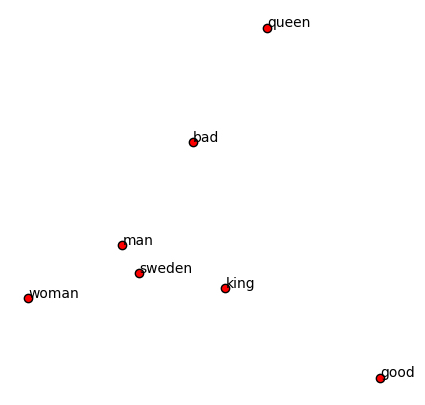

In [38]:
# Optional — PCA visualization

from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

def plot_embeddings_pca(emb, voc, words):
    vectors = np.vstack([emb.weight[voc[w]].cpu().detach().numpy() for w in words])
    vectors -= vectors.mean(axis=0)
    twodim = TruncatedSVD(n_components=2).fit_transform(vectors)
    plt.figure(figsize=(5, 5))
    plt.scatter(twodim[:, 0], twodim[:, 1], edgecolors='k', c='r')
    for word, (x, y) in zip(words, twodim):
        plt.text(x + 0.02, y, word)
    plt.axis('off')
    plt.show()

sample_words = [w for w in ["king", "queen", "man", "woman", "sweden", "good", "bad"] if w in voc]
if sample_words:
    plot_embeddings_pca(model.embedding, voc, sample_words)
